# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping
source_category = {
    'Coal': 'Fossil',
    'Oil': 'Fossil',
    'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon',
    'Hydro': 'Low-carbon',
    'Wind': 'Renewable',
    'Solar': 'Renewable',
    'Other Renewables': 'Renewable'
}

df['Source_Type'] = df['Source'].map(source_category)

print(df.head()) 

         Country         Region       Source  Share_pct     TWh Source_Type
0  United States  North America         Coal         10  1015.0      Fossil
1  United States  North America          Oil         35  3220.0      Fossil
2  United States  North America  Natural Gas         34  3083.0      Fossil
3  United States  North America      Nuclear          9   798.0  Low-carbon
4  United States  North America        Hydro          3   339.0  Low-carbon


## Task 1 — Treemap: fossil fuel dependency by country

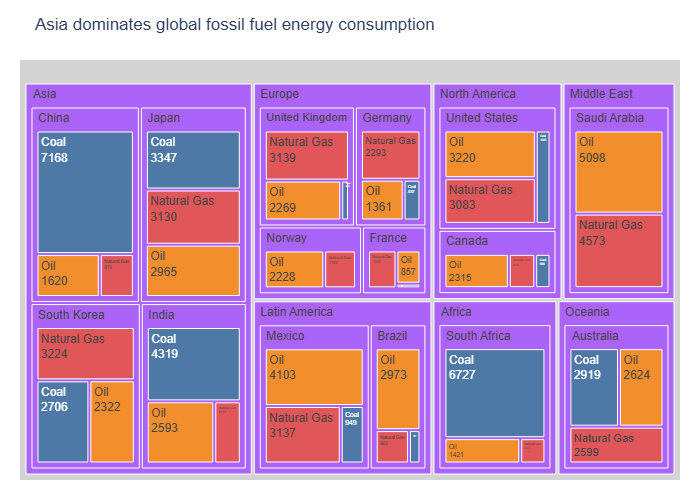

In [10]:
fossil_df = df[df['Source_Type'] == 'Fossil']

fig = px.treemap(
    fossil_df,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4E79A7',
        'Oil': '#F28E2B',
        'Natural Gas': '#E15759'
    },
    title='Asia dominates global fossil fuel energy consumption'
)

fig.update_traces(
    textinfo='label+value',
    root_color='lightgrey'
)

fig.update_layout(
    template='plotly_white',
    font_family='Arial',
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()
fig.show(renderer="png")

## Task 2 — Sunburst: tipping behaviour by day and meal time

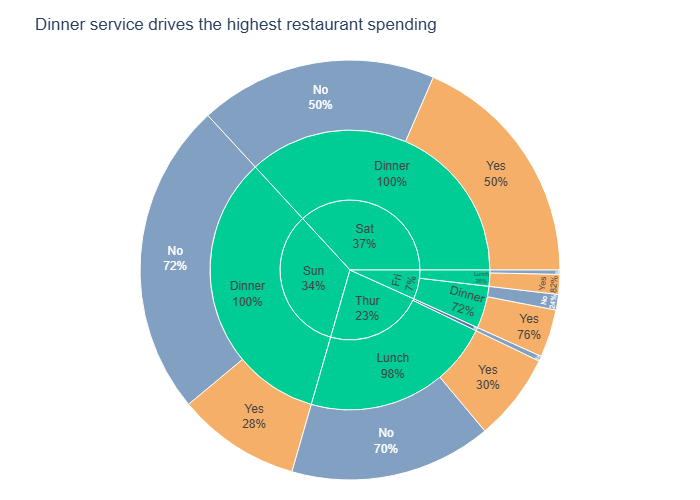

In [11]:
tips = px.data.tips()

tips_sum = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

fig = px.sunburst(
    tips_sum,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#F28E2B',
        'No': '#4E79A7'
    },
    title='Dinner service drives the highest restaurant spending'
)

fig.update_traces(
    textinfo='label+percent parent',
    root_color='lightgrey'
)

fig.update_layout(
    template='plotly_white',
    font_family='Arial',
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()
fig.show(renderer="png")

## Task 3 — Treemap vs bar: low-carbon energy by country

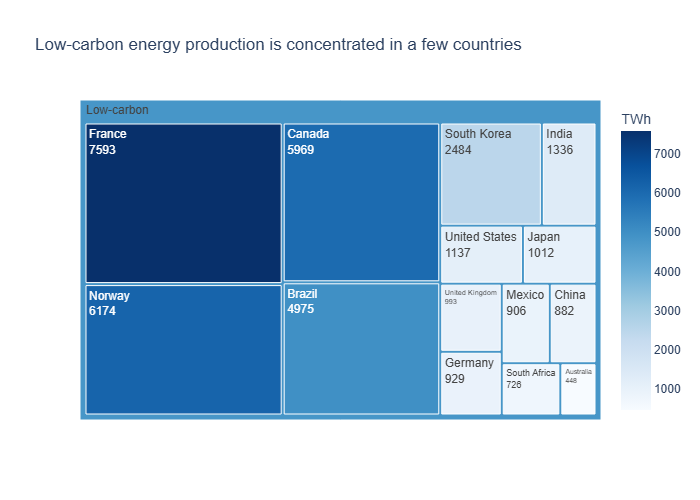

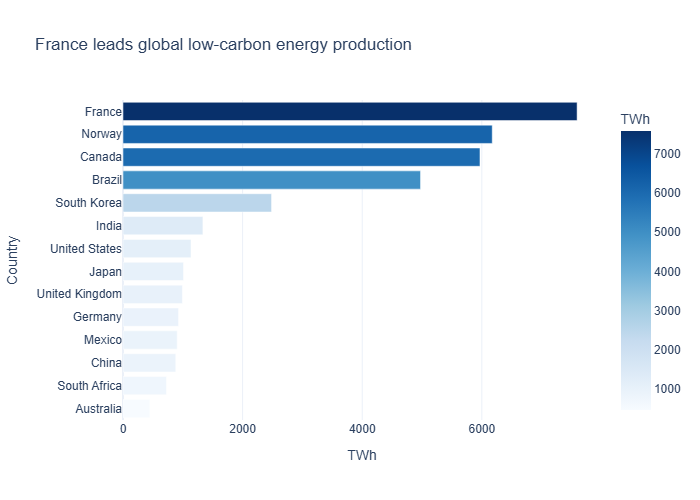

In [12]:
low_df = (
    df[df['Source_Type'] == 'Low-carbon']
    .groupby('Country')['TWh']
    .sum()
    .reset_index()
)

low_df = low_df.sort_values('TWh', ascending=False)

# Treemap

low_df['All'] = 'Low-carbon'

fig1 = px.treemap(
    low_df,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-carbon energy production is concentrated in a few countries'
)

fig1.update_traces(textinfo='label+value')

fig1.update_layout(
    template='plotly_white',
    font_family='Arial'
)

fig1.show()
fig1.show(renderer="png")

# Bar chart

fig2 = px.bar(
    low_df.head(15),
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    title=f"{low_df.iloc[0]['Country']} leads global low-carbon energy production"
)

fig2.update_layout(
    template='plotly_white',
    font_family='Arial',
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False
)

fig2.show()
fig2.show(renderer="png")